In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("../data/adult.csv")

print("Shape:", df.shape)
display(df.head())
print(df.columns)

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')


In [3]:
# Replace common missing value symbols
df = df.replace("?", np.nan)
df = df.replace(" ?", np.nan)

# Drop rows with missing values
df = df.dropna()

# Remove extra spaces from text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Shape after cleaning:", df.shape)
display(df.head())

Shape after cleaning: (45222, 15)


C:\Users\ivpri\AppData\Local\Temp\ipykernel_11056\2950687398.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [4]:
print(df["income"].value_counts())

income
<=50K    34014
>50K     11208
Name: count, dtype: int64


In [ ]:
# define x and y for building model

X = df.drop(columns=["income"])
y = df["income"]

# Encode target labels as numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target examples:", y_encoded[:10])

Classes: ['<=50K' '>50K']
Encoded target examples: [0 0 1 1 0 1 0 0 1 0]


In [6]:
# encode cats
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)
display(X_encoded.head())

Original feature shape: (45222, 14)
Encoded feature shape: (45222, 96)


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,198693,6,0,0,30,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [7]:
# train/validation/test splits
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (28941, 96)
Validation shape: (7236, 96)
Test shape: (9045, 96)


In [8]:
# scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

input_shape = X_train_scaled.shape[1]
print("Number of input features:", input_shape)

Number of input features: 96


In [9]:
# save results, make function for plotting histories, and function for evaluating on test set
results = []
histories = {}

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.show()


def evaluate_model(model, model_name, history):
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Epochs Run": len(history.history["loss"]),
        "Final Training Accuracy": history.history["accuracy"][-1],
        "Best Validation Accuracy": max(history.history["val_accuracy"]),
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1
    })

    print(model_name)
    print("Test Accuracy:", round(accuracy, 4))
    print("Test Precision:", round(precision, 4))
    print("Test Recall:", round(recall, 4))
    print("Test F1:", round(f1, 4))
    print()
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    plot_history(history, model_name)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8121 - loss: 0.3970 - val_accuracy: 0.8365 - val_loss: 0.3471
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8447 - loss: 0.3352 - val_accuracy: 0.8449 - val_loss: 0.3349
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8477 - loss: 0.3252 - val_accuracy: 0.8463 - val_loss: 0.3298
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8509 - loss: 0.3197 - val_accuracy: 0.8473 - val_loss: 0.3274
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8530 - loss: 0.3165 - val_accuracy: 0.8478 - val_loss: 0.3251
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8543 - loss: 0.3138 - val_accuracy: 0.8495 - val_loss: 0.3236
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8554 - loss: 0.3118 - val_accuracy: 0.8494 - val_loss: 0.3227
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8558 - loss: 0.3100 - val_accuracy: 

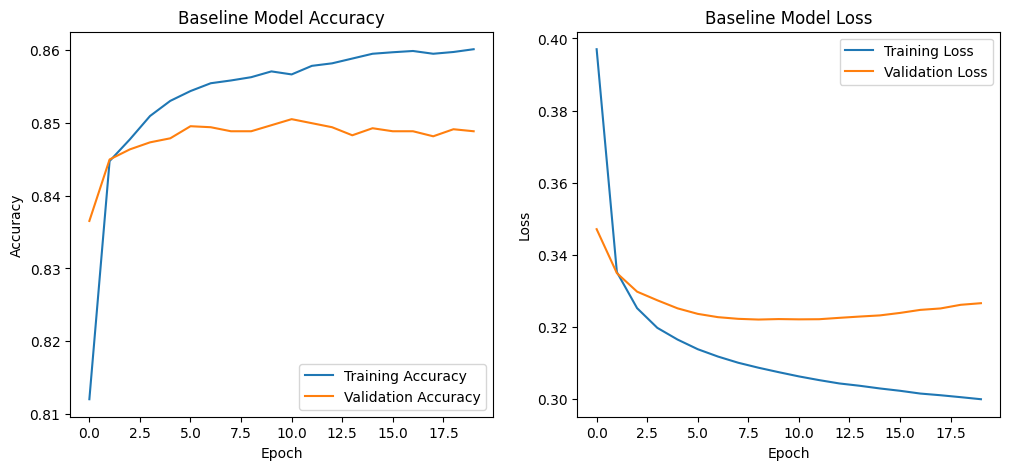

In [10]:
# base NN
# random seed for reproducibility
tf.random.set_seed(42)

inputs = keras.Input(shape=(input_shape,))
x = layers.Dense(16, activation="relu")(inputs)
x = layers.Dense(8, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

baseline_model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_model")

baseline_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

evaluate_model(baseline_model, "Baseline Model", baseline_history)
histories["Baseline Model"] = baseline_history

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8326 - loss: 0.3585 - val_accuracy: 0.8449 - val_loss: 0.3322
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8489 - loss: 0.3234 - val_accuracy: 0.8491 - val_loss: 0.3243
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8527 - loss: 0.3150 - val_accuracy: 0.8510 - val_loss: 0.3215
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8546 - loss: 0.3101 - val_accuracy: 0.8510 - val_loss: 0.3206
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8563 - loss: 0.3061 - val_accuracy: 0.8510 - val_loss: 0.3206
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8573 - loss: 0.3031 - val_accuracy: 0.8495 - val_loss: 0.3214
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8590 - loss: 0.3004 - val_accuracy: 0.8488 - val_loss: 0.3226
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8607 - loss: 0.2978 - val_accuracy: 0.

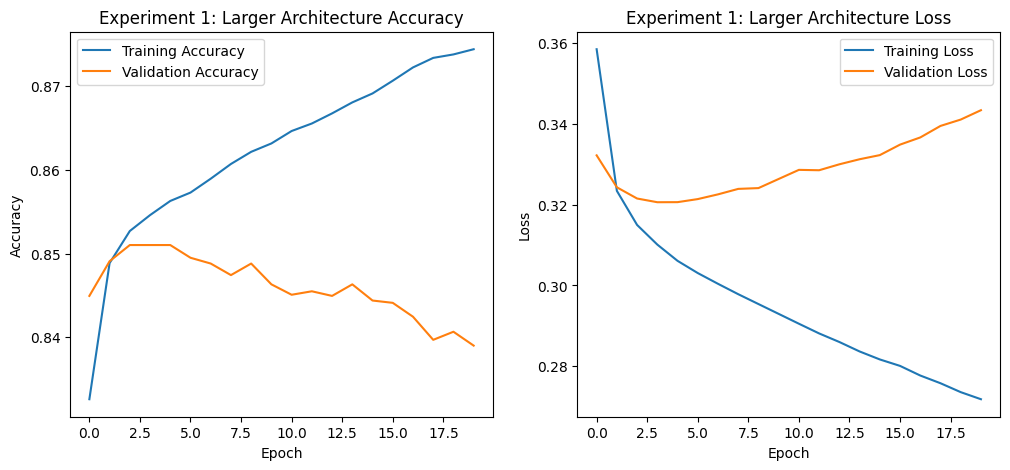

In [11]:
# iteration 1: larger architecture

tf.random.set_seed(42)

inputs = keras.Input(shape=(input_shape,))
x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

larger_model = keras.Model(inputs=inputs, outputs=outputs, name="larger_model")

larger_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

larger_history = larger_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

evaluate_model(larger_model, "Experiment 1: Larger Architecture", larger_history)
histories["Experiment 1: Larger Architecture"] = larger_history

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8140 - loss: 0.4021 - val_accuracy: 0.8391 - val_loss: 0.3422
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8390 - loss: 0.3496 - val_accuracy: 0.8463 - val_loss: 0.3308
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8459 - loss: 0.3362 - val_accuracy: 0.8491 - val_loss: 0.3248
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8474 - loss: 0.3291 - val_accuracy: 0.8507 - val_loss: 0.3225
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8506 - loss: 0.3257 - val_accuracy: 0.8496 - val_loss: 0.3209
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8526 - loss: 0.3223 - val_accuracy: 0.8514 - val_loss: 0.3202
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8528 - loss: 0.3218 - val_accuracy: 0.8485 - val_loss: 0.3208
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8550 - loss: 0.3179 - val_accuracy: 

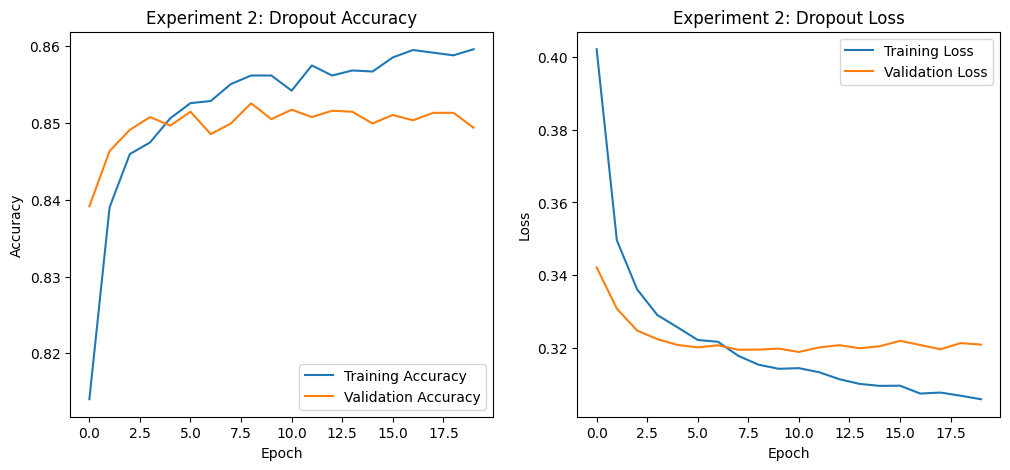

In [12]:
# iteration 2: dropout
tf.random.set_seed(42)

inputs = keras.Input(shape=(input_shape,))
x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

dropout_model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")

dropout_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

evaluate_model(dropout_model, "Experiment 2: Dropout", dropout_history)
histories["Experiment 2: Dropout"] = dropout_history

Epoch 1/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8339 - loss: 0.6123 - val_accuracy: 0.8404 - val_loss: 0.3861
Epoch 2/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8423 - loss: 0.3701 - val_accuracy: 0.8422 - val_loss: 0.3622
Epoch 3/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8439 - loss: 0.3585 - val_accuracy: 0.8438 - val_loss: 0.3564
Epoch 4/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8450 - loss: 0.3535 - val_accuracy: 0.8445 - val_loss: 0.3534
Epoch 5/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8463 - loss: 0.3502 - val_accuracy: 0.8452 - val_loss: 0.3502
Epoch 6/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.3471 - val_accuracy: 0.8474 - val_loss: 0.3479
Epoch 7/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8482 - loss: 0.3449 - val_accuracy: 0.8476 - val_loss: 0.3456
Epoch 8/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8489 - loss: 0.3427 - val_accuracy: 0.

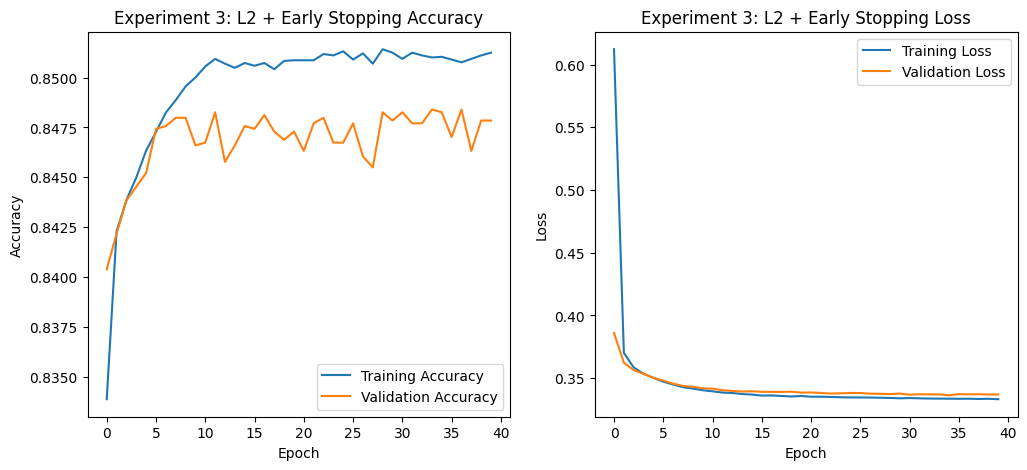

In [13]:
# iteration 3: early stopping + l2 regularization
tf.random.set_seed(42)

inputs = keras.Input(shape=(input_shape,))
x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)
)(inputs)
x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)
)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

regularized_model = keras.Model(inputs=inputs, outputs=outputs, name="regularized_model")

regularized_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

regularized_history = regularized_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(regularized_model, "Experiment 3: L2 + Early Stopping", regularized_history)
histories["Experiment 3: L2 + Early Stopping"] = regularized_history

In [14]:
results_df = pd.DataFrame(results)
display(results_df)

,Model,Epochs Run,Final Training Accuracy,Best Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Baseline Model,20,0.860060,0.850470,0.843892,0.714138,0.617306,0.662201
1,Experiment 1: Larger Architecture,20,0.874434,0.851023,0.841349,0.700846,0.628011,0.662432
2,Experiment 2: Dropout,20,0.859576,0.852543,0.847651,0.767658,0.552632,0.642635
3,Experiment 3: L2 + Early Stopping,40,0.851249,0.848397,0.844887,0.709227,0.634255,0.669649


### Experiment comparison before tuning

The baseline NN model used two small hidden layers. Experiment 1 changed one factor by increasing the size of the hidden layers from 16 and 8 units to 64 and 32 units. This tested whether adding more model capacity improved performance. Experiment 2 kept the larger architecture but added dropout, which tested to see if regularization could reduce overfitting. Experiment 3 used the same larger structure but added L2 regularization and early stopping, which tested whether penalizing large weights and stopping training earlier improved validation.

The results were pretty close across the models, suggesting that this dataset does not require a very complex neural network to reach reasonable performance. The larger architecture very slightly improved validation accuracy but also had the highest training accuracy, so it showed a little more risk of overfitting. Dropout gave the highest validation accuracy among the manual experiments, but it had lower recall for the >50K class. The L2 plus early stopping model had the best F1 score among the manual experiments, meaning it gave the best balance between precision and recall. These experiments show why it's important to compare more than accuracy. A model can have slightly higher accuracy while doing worse on recall or F1 score. 


start optuna work

In [15]:
import optuna

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# optuna tuning stuff
def objective(trial):
    tf.random.set_seed(42)

    num_layers = trial.suggest_int("num_layers", 1, 3)
    units = trial.suggest_categorical("units", [16, 32, 64, 128])
    learning_rate = trial.suggest_float("learning_rate", 0.0001, 0.01, log=True)
    dropout_rate = trial.suggest_categorical("dropout_rate", [0.0, 0.2, 0.3, 0.4])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    inputs = keras.Input(shape=(input_shape,))
    x = inputs

    for i in range(num_layers):
        x = layers.Dense(units, activation="relu")(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=40,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])
    return val_accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best validation accuracy:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-05-21 15:30:49,496] A new study created in memory with name: no-name-503eef9c-21d1-4b63-89a4-dbfca2b34614
[I 2026-05-21 15:31:45,156] Trial 0 finished with value: 0.8525428175926208 and parameters: {'num_layers': 3, 'units': 128, 'learning_rate': 0.0003293563611973509, 'dropout_rate': 0.4, 'batch_size': 32}. Best is trial 0 with value: 0.8525428175926208.
[I 2026-05-21 15:39:15,090] Trial 1 finished with value: 0.8504698872566223 and parameters: {'num_layers': 3, 'units': 32, 'learning_rate': 0.0002026503689530276, 'dropout_rate': 0.4, 'batch_size': 16}. Best is trial 0 with value: 0.8525428175926208.
[I 2026-05-21 15:40:32,763] Trial 2 finished with value: 0.8508844375610352 and parameters: {'num_layers': 3, 'units': 32, 'learning_rate': 0.00014743472408820573, 'dropout_rate': 0.4, 'batch_size': 64}. Best is trial 0 with value: 0.8525428175926208.
[I 2026-05-21 15:41:17,210] Trial 3 finished with value: 0.848949670791626 and parameters: {'num_layers': 2, 'units': 128, 'learnin

Best validation accuracy: 0.8536484241485596
Best parameters:
{'num_layers': 2, 'units': 32, 'learning_rate': 0.0027176074535415836, 'dropout_rate': 0.0, 'batch_size': 64}


In [17]:
# results
optuna_results = study.trials_dataframe()
display(optuna_results.sort_values("value", ascending=False).head(10))

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_learning_rate,params_num_layers,params_units,state
7,7,0.853648,2026-05-21 15:45:39.734609,2026-05-21 15:46:11.229299,0 days 00:00:31.494690,64,0.0,0.002718,2,32,COMPLETE
13,13,0.853510,2026-05-21 15:50:24.712146,2026-05-21 15:50:43.389721,0 days 00:00:18.677575,64,0.2,0.001379,2,64,COMPLETE
17,17,0.853372,2026-05-21 15:51:43.832911,2026-05-21 15:52:07.935181,0 days 00:00:24.102270,64,0.0,0.006648,1,32,COMPLETE
12,12,0.853372,2026-05-21 15:49:18.263696,2026-05-21 15:50:24.711144,0 days 00:01:06.447448,32,0.2,0.001351,3,64,COMPLETE
18,18,0.852957,2026-05-21 15:52:07.938207,2026-05-21 15:52:48.945413,0 days 00:00:41.007206,64,0.2,0.001283,1,64,COMPLETE
0,0,0.852543,2026-05-21 15:30:49.498182,2026-05-21 15:31:45.156968,0 days 00:00:55.658786,32,0.4,0.000329,3,128,COMPLETE
14,14,0.851852,2026-05-21 15:50:43.391691,2026-05-21 15:50:58.780048,0 days 00:00:15.388357,64,0.2,0.001586,2,64,COMPLETE
4,4,0.851575,2026-05-21 15:41:17.212016,2026-05-21 15:44:15.974005,0 days 00:02:58.761989,16,0.4,0.000492,1,32,COMPLETE
8,8,0.851437,2026-05-21 15:46:11.233864,2026-05-21 15:46:58.074500,0 days 00:00:46.840636,64,0.2,0.000864,2,32,COMPLETE
16,16,0.851161,2026-05-21 15:51:18.431728,2026-05-21 15:51:43.830899,0 days 00:00:25.399171,64,0.2,0.002182,2,64,COMPLETE


Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8292 - loss: 0.3610 - val_accuracy: 0.8462 - val_loss: 0.3321
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8487 - loss: 0.3237 - val_accuracy: 0.8467 - val_loss: 0.3229
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.3165 - val_accuracy: 0.8481 - val_loss: 0.3213
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3122 - val_accuracy: 0.8491 - val_loss: 0.3204
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8572 - loss: 0.3086 - val_accuracy: 0.8484 - val_loss: 0.3205
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8584 - loss: 0.3055 - val_accuracy: 0.8491 - val_loss: 0.3217
Epoch 7/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.3025 - val_accuracy: 0.8501 - val_loss: 0.3240
Epoch 8/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3001 - val_accuracy: 0.

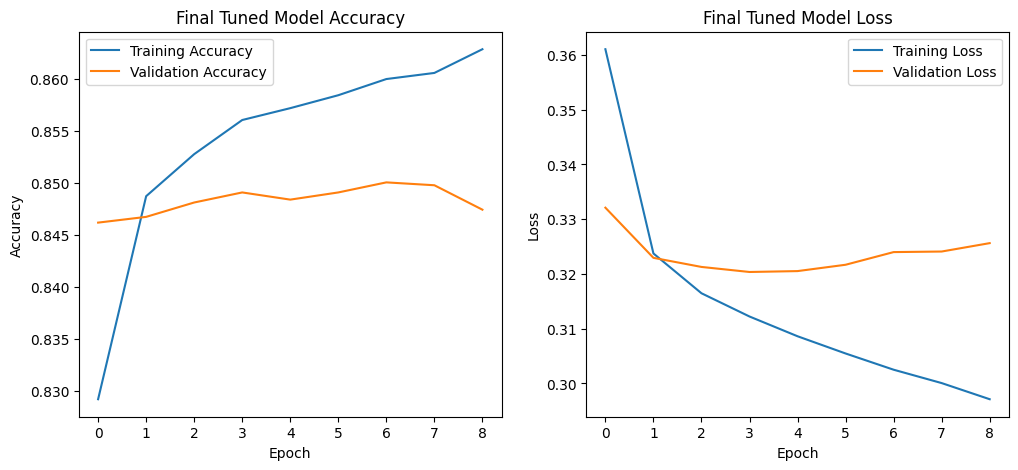

In [18]:
# build final tuned model
best_params = study.best_params

tf.random.set_seed(42)

inputs = keras.Input(shape=(input_shape,))
x = inputs

for i in range(best_params["num_layers"]):
    x = layers.Dense(best_params["units"], activation="relu")(x)

    if best_params["dropout_rate"] > 0:
        x = layers.Dropout(best_params["dropout_rate"])(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

final_model = keras.Model(inputs=inputs, outputs=outputs, name="final_tuned_model")

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(final_model, "Final Tuned Model", final_history)
histories["Final Tuned Model"] = final_history


In [19]:
final_results_df = pd.DataFrame(results)
display(final_results_df.sort_values("Test F1", ascending=False))

,Model,Epochs Run,Final Training Accuracy,Best Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
3,Experiment 3: L2 + Early Stopping,40,0.851249,0.848397,0.844887,0.709227,0.634255,0.669649
4,Final Tuned Model,9,0.862859,0.850055,0.848646,0.740496,0.599465,0.662559
1,Experiment 1: Larger Architecture,20,0.874434,0.851023,0.841349,0.700846,0.628011,0.662432
0,Baseline Model,20,0.860060,0.850470,0.843892,0.714138,0.617306,0.662201
2,Experiment 2: Dropout,20,0.859576,0.852543,0.847651,0.767658,0.552632,0.642635


### Final model 

The best Optuna trial selected a model with 2 hidden layers, 32 units, a learning rate around 0.0027, no dropout, and a batch size of 64.

The final tuned model had the highest test accuracy overall, about 0.849. However, the L2 plus early stopping model had the highest test F1 score, about 0.670. This means the tuned model was strongest if the main goal was overall accuracy, while the L2 plus early stopping model was slightly better if the goal was balancing precision/recall for predicting the higher-income class.

The training and validation curves suggest that the final tuned model learned quickly and then stopped after a small number of epochs because validation loss just stopped improving. This can be useful as it reduces unnecessary training and helps limit overfitting. The final model didn't significantly outperform the other models, but the tuning process was still useful because it confirmed that a moderately sized network was enough for this dataset.


### Personal workflow for building neural networks

1. Clean the data first by handling missing values, checking the target variable, encoding categorical variables, and scaling the input features.
2. Split the data into training, validation, and test sets before modeling. I would use the validation set during model development and save the test set for final evaluation only.
3. Start with a simple baseline model so I have a reference point.
4. Run controlled experiments where I change one factor at a time, such as the number of hidden layers, number of neurons, dropout, L2 regularization, early stopping, batch size, or learning rate.
5. Compare models using both metrics and learning curves. I would look at accuracy, precision, recall, F1 score, training loss, and validation loss rather than relying on accuracy alone.
6. Use a systematic tuning method such as Optuna after the manual experiments. This helps search combinations of hyperparameters more consistently than guessing..
7. Choose the final model based on the project goal. If overall correctness matters most, I would prioritize accuracy. If the positive class is especially important, I would pay closer attention to recall and F1 score.
8. Watch for overfitting. If training accuracy keeps improving while validation performance stops improving or gets worse, I would consider dropout, L2 regularization, early stopping, or a simpler model.

A big learning lesson I took away was that a more complex model is not automatically better. In this assignment, the models performed similarly, and the best choice depended on which metric I prioritized.
